# Template for making figure of PCRglobwb output

In [1]:
import glob

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm

In [2]:
# output_folder = "../../model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/netcdf"
output_folder = "../../model_runs/pcrglobwb/test_shapefile/own_files"


# Add a pattern to select .nc files
files = sorted(glob.glob(f"{output_folder}/*.nc"))

# Check if any files were found
print("Found files:", files)

# Open all datasets
datasets = [xr.open_dataset(f, engine="netcdf4") for f in files]

Found files: ['../../model_runs/pcrglobwb/test_shapefile/own_files/discharge_dailyTot_output.nc', '../../model_runs/pcrglobwb/test_shapefile/own_files/gwRecharge_dailyTot_output.nc', '../../model_runs/pcrglobwb/test_shapefile/own_files/surfaceWaterStorage_dailyTot_output.nc', '../../model_runs/pcrglobwb/test_shapefile/own_files/totalGroundwaterAbstraction_dailyTot_output.nc', '../../model_runs/pcrglobwb/test_shapefile/own_files/totalRunoff_dailyTot_output.nc']


In [3]:
for i, f in enumerate(files, start=1):
    print(i, f)

1 ../../model_runs/pcrglobwb/test_shapefile/own_files/discharge_dailyTot_output.nc
2 ../../model_runs/pcrglobwb/test_shapefile/own_files/gwRecharge_dailyTot_output.nc
3 ../../model_runs/pcrglobwb/test_shapefile/own_files/surfaceWaterStorage_dailyTot_output.nc
4 ../../model_runs/pcrglobwb/test_shapefile/own_files/totalGroundwaterAbstraction_dailyTot_output.nc
5 ../../model_runs/pcrglobwb/test_shapefile/own_files/totalRunoff_dailyTot_output.nc


In [14]:
ds_selected = datasets[4]
print(ds_selected)

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 9, lat: 180, lon: 288)
Coordinates:
  * time          (time) datetime64[ns] 72B 1990-01-01 1990-01-02 ... 1990-01-09
  * lat           (lat) float32 720B 47.96 47.88 47.79 ... 33.21 33.12 33.04
  * lon           (lon) float32 1kB 53.04 53.12 53.21 ... 76.79 76.88 76.96
Data variables:
    total_runoff  (time, lat, lon) float32 2MB ...
Attributes:
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output, with human factors (non-natural)
    description:  PCR-GLOBWB run with human factors (non-natural) at 5 arcmin...


In [15]:
# select variable and time
subset = ds_selected["total_runoff"].isel(
    time=-1  # Select a specific time if applicable
)


# possible subset selection for logaritmic scaling
# subset = subset.where(subset > 1)

In [16]:
fig = plt.figure(figsize=(10, 8), dpi=200)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Convert time and name
time_str = pd.to_datetime(subset.time.values).strftime("%Y-%m-%d")
variable_name = subset.standard_name.capitalize()

mappable = subset.plot(
    ax=ax,
    cmap="GnBu",
    norm=LogNorm(vmin=subset.min(), vmax=subset.max()),
    add_colorbar=False,  # prevent xarray from adding a default colorbar
)

# Add colorbar manually
cbar = fig.colorbar(
    mappable,  # <-- THIS is the QuadMesh returned by plot()
    ax=ax,
    orientation="vertical",
    shrink=0.7,
    aspect=25,
    pad=0.02,
    # extend = 'both'
)
cbar.set_label(f"{variable_name} [{subset.units}]")


# Coastlines and other features
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set map extent
ax.set_extent([53, 80, 33, 50])

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


# Legend
ax.legend(loc="upper right")


# Dynamic title
title = f"{variable_name} on {time_str}, modelled by PCR-GLOBWB2"

# Title
ax.set_title(title, fontsize=12)


plt.savefig("../../outputs/figures/PCR_output.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f484a44b2e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 2000x1600 with 2 Axes>

In [17]:
print(np.nanmin(subset), np.nanmax(subset))
print(np.isfinite(subset).sum())

nan nan
<xarray.DataArray 'total_runoff' ()> Size: 8B
array(0)
Coordinates:
    time     datetime64[ns] 8B 1990-01-09


/tmp/ipykernel_53778/1405060071.py:3: RuntimeWarning: All-NaN axis encountered
  print(np.nanmin(subset), np.nanmax(subset))


In [12]:
ds_selected["discharge"].isel(time=0).notnull().sum()

<xarray.DataArray 'discharge' ()> Size: 8B
array(0)
Coordinates:
    time     datetime64[ns] 8B 1990-01-01

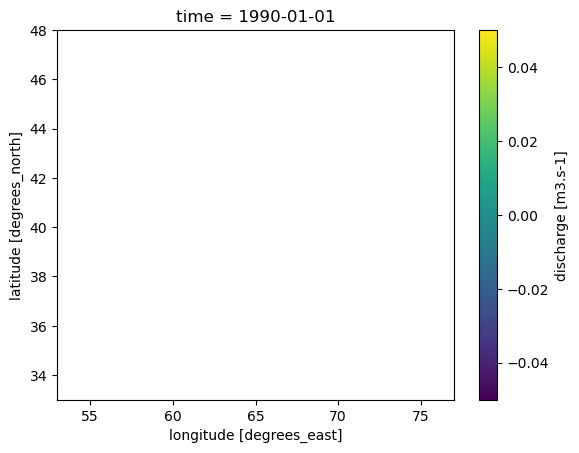

In [13]:
ds_selected["discharge"].isel(time=0).plot()